# LIBRAIRIES

In [1]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

# DATA

In [2]:
# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────

root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/COMPACTION__PSMN__2026-04-21")
paths = [str(p) for p in root.rglob("*.parquet")]               # root + all levels of depth

In [3]:
# ─────────────────────────────────────────────
# DATA FRAME
# ─────────────────────────────────────────────

# Filtering on (μ, θ)
mu    = 150
theta = 100


# Loading data
ARRAY_COLS = ["results", "results_mean", "alpha_mean_a"]

df_data = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("mu")    == mu) &
        (pl.col("theta") == theta)
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "alphad"])
)

# Printing data
print(df_data)
print(df_data.columns)

shape: (445, 63)
┌──────┬───────┬──────┬──────┬───┬───────┬────────┬───────────┬────────────┐
│ algo ┆ fact  ┆ mode ┆ dstr ┆ … ┆ dt_mp ┆ alpha0 ┆ bound_low ┆ bound_high │
│ ---  ┆ ---   ┆ ---  ┆ ---  ┆   ┆ ---   ┆ ---    ┆ ---       ┆ ---        │
│ str  ┆ bool  ┆ str  ┆ bool ┆   ┆ f64   ┆ i64    ┆ i64       ┆ i64        │
╞══════╪═══════╪══════╪══════╪═══╪═══════╪════════╪═══════════╪════════════╡
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ …    ┆ …     ┆ …    ┆ …    ┆ … ┆ …     ┆ …      ┆ …         ┆ …          │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5      

# RANDOM - DATA

In [4]:
# ─────────────────────────────────────────────
# LOADING
# ─────────────────────────────────────────────

df_random = df_data.filter(
    (pl.col("land") == "random") 
)
print(df_random)


# ─────────────────────────────────────────────
# EXTRACTION DES VALEURS
# ─────────────────────────────────────────────

land         = df_random["land"].to_list()[0]
mu           = df_random["mu"].to_numpy()[0]
th           = df_random["theta"].to_numpy()[0]
s            = df_random["s"].to_numpy()[0]
Lmin         = df_random["Lmin"].to_numpy()[0]
Lmax         = df_random["Lmax"].to_numpy()[0]
bps          = df_random["bps"].to_numpy()[0]
tmax         = df_random["tmax"].to_numpy()[0]
dt           = df_random["dt"].to_numpy()[0]

l            = df_random["l"].to_numpy()
bpmin        = df_random["bpmin"].to_numpy()
results      = df_random["results"].to_numpy()
results_mean = df_random["results_mean"].to_numpy()
v_mean       = df_random["v_mean"].to_numpy()
vi_med       = df_random["vi_med"].to_numpy()
wf           = df_random["wf"].to_numpy()

l_values     = np.unique(l)
bpmin_values = np.unique(bpmin)

d            = 1 / (s + l)
v_th         = mu * d * l
ratio        = v_mean / v_th
c            = (150 + l) / (35 + l)
v_mean_bp    = v_mean * c

chromatin    = np.arange(Lmin, Lmax, bps)
time         = np.arange(0, tmax, dt)

# Colormap partagée (bpmin)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=bpmin_values.min(), vmax=bpmin_values.max())

shape: (225, 63)
┌──────┬───────┬──────┬──────┬───┬───────┬────────┬───────────┬────────────┐
│ algo ┆ fact  ┆ mode ┆ dstr ┆ … ┆ dt_mp ┆ alpha0 ┆ bound_low ┆ bound_high │
│ ---  ┆ ---   ┆ ---  ┆ ---  ┆   ┆ ---   ┆ ---    ┆ ---       ┆ ---        │
│ str  ┆ bool  ┆ str  ┆ bool ┆   ┆ f64   ┆ i64    ┆ i64       ┆ i64        │
╞══════╪═══════╪══════╪══════╪═══╪═══════╪════════╪═══════════╪════════════╡
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ …    ┆ …     ┆ …    ┆ …    ┆ … ┆ …     ┆ …      ┆ …         ┆ …          │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5         ┆ 80         │
│ 1S   ┆ false ┆ none ┆ true ┆ … ┆ 0.5   ┆ 1      ┆ 5      

# RANDOM - FIGURES

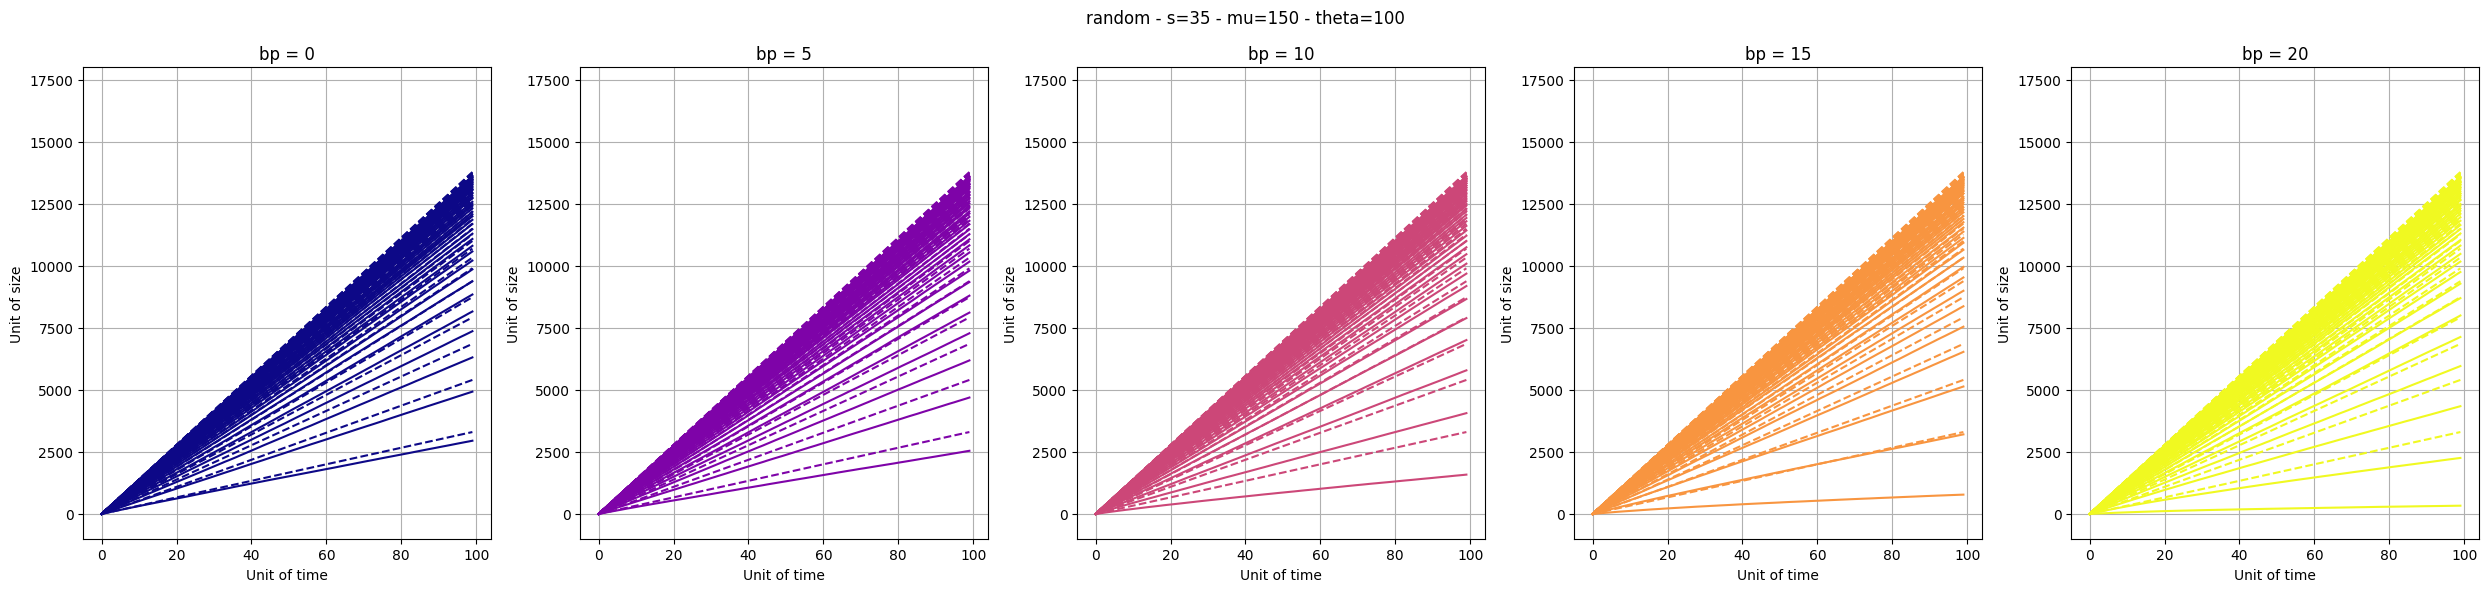

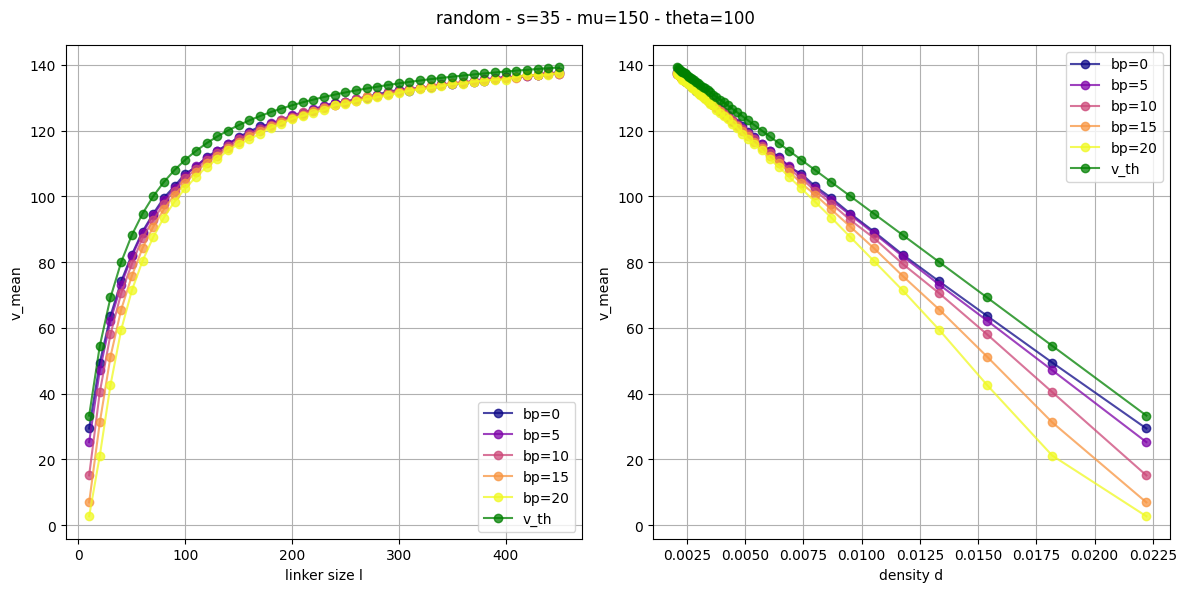

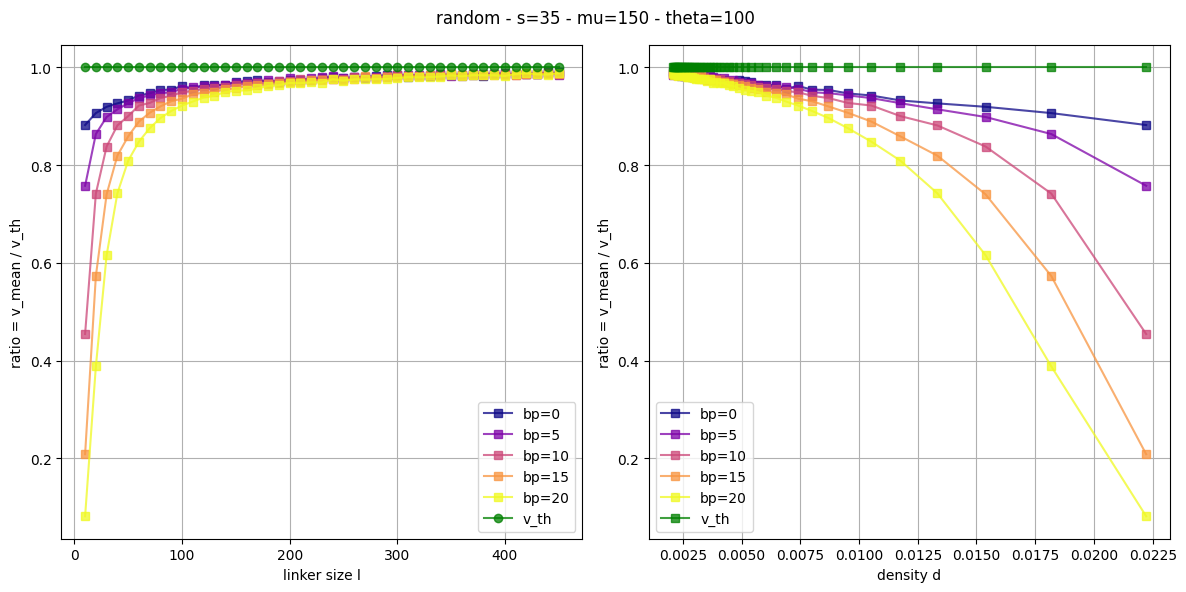

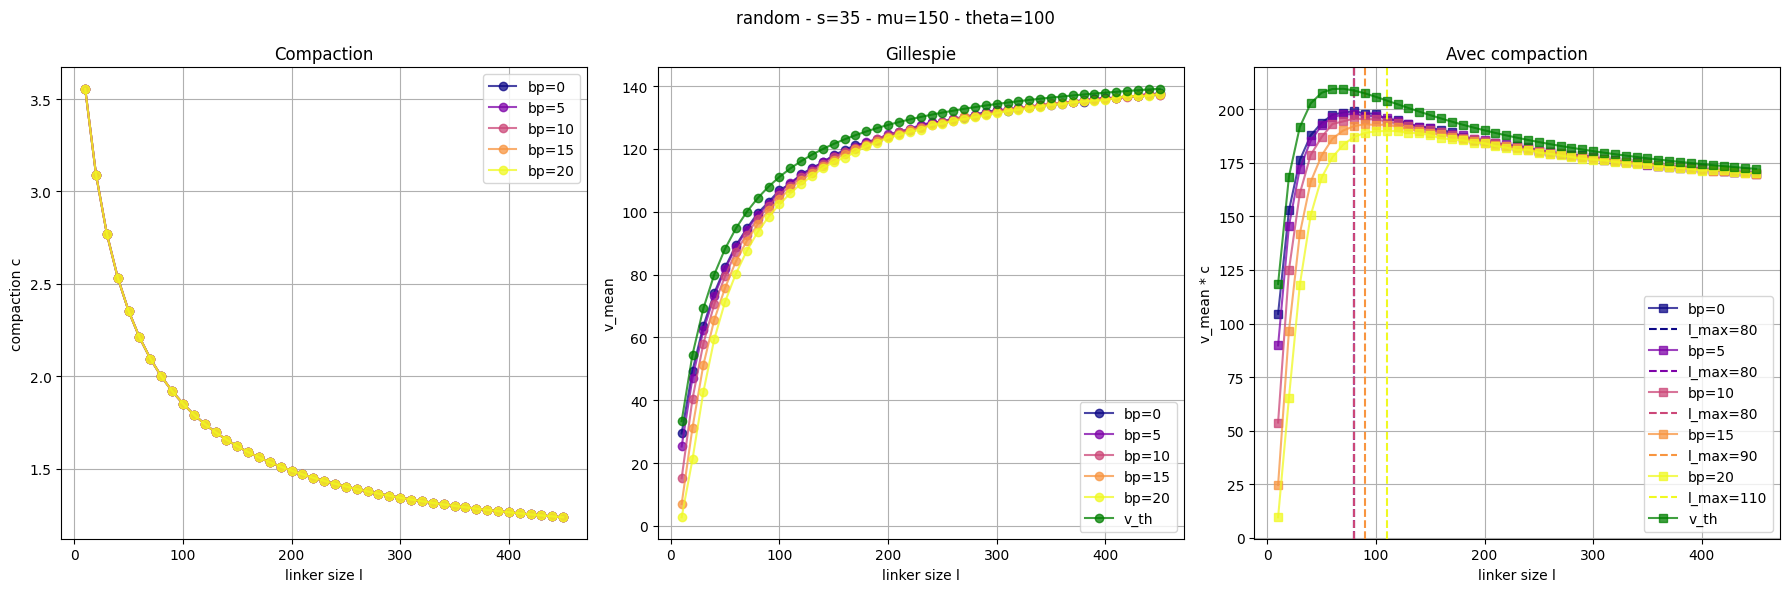

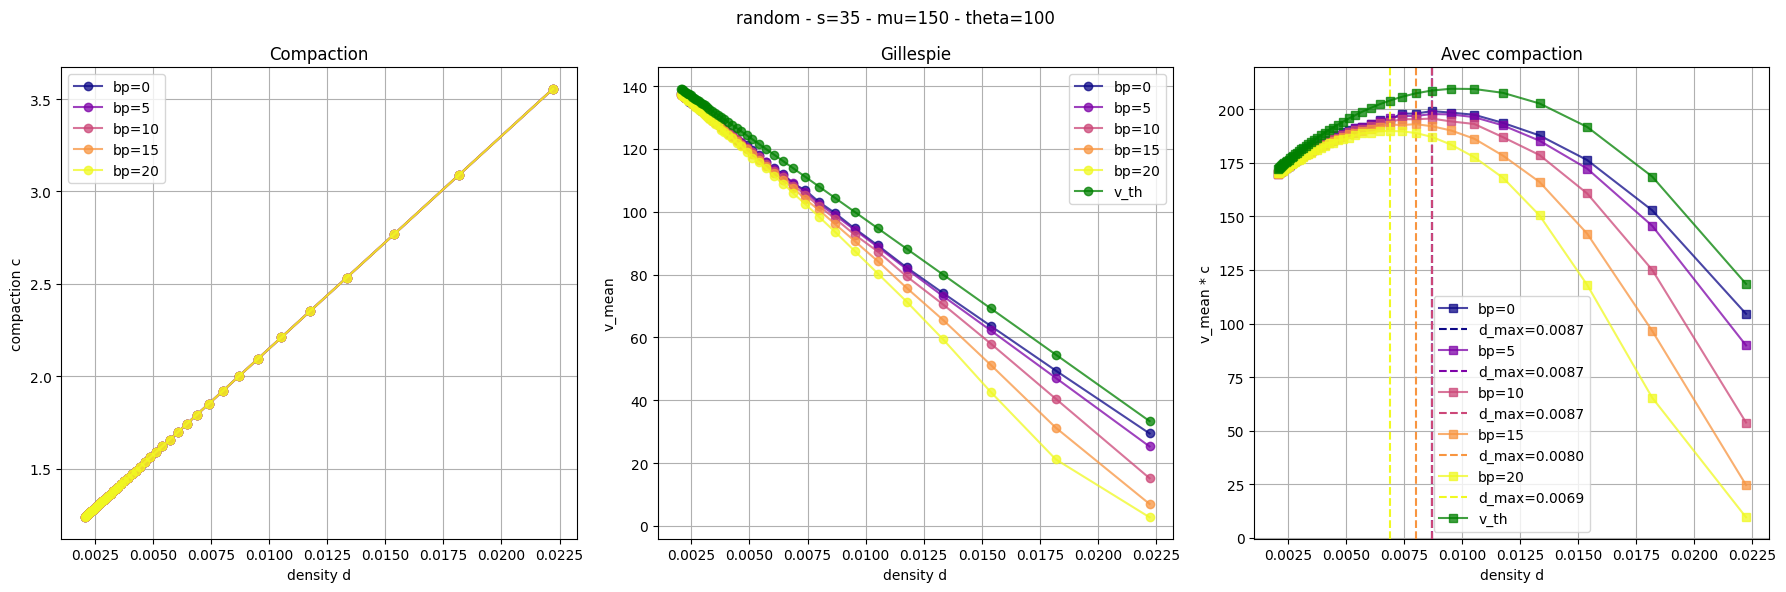

In [5]:
# ─────────────────────────────────────────────
# FIGURE 1 — Trajectoires
# ─────────────────────────────────────────────

nc  = len(bpmin_values)
fig, axs = plt.subplots(1, nc, figsize=(5 * nc, 6))
plt.suptitle(f"{land} - s={s} - mu={mu} - theta={th}")

if nc == 1:
    axs = [axs]

for ax, bp in zip(axs, bpmin_values):
    df_bp        = df_random.filter(pl.col("bpmin") == bp)
    results_bp   = df_bp["results_mean"].to_numpy()
    wf_bp        = df_bp["wf"].to_numpy()
    l_bp         = df_bp["l"].to_numpy()
    d_bp         = 1 / (s + l_bp)
    v_th_bp      = mu * d_bp * l_bp

    for res, l_val, d_val, v_th_val, wf_val in zip(results_bp, l_bp, d_bp, v_th_bp, wf_bp):
        color = cmap(norm(bp))
        ax.plot(time, res,            color=color, ls="-",  label=f"l={l_val} - d={d_val:.3f} model - wf={wf_val}")
        ax.plot(time, time * v_th_val, color=color, ls="--", label=f"l={l_val} - d={d_val:.3f} theo  - wf={wf_val}")

    ax.set_title(f"bp = {bp}")
    ax.set_xlabel("Unit of time")
    ax.set_ylabel("Unit of size")
    ax.set_ylim([-1_000, 18_000])
    ax.grid(True, which="both")

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 2 — v_mean vs l et vs d
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plt.suptitle(f"{land} - s={s} - mu={mu} - theta={th}")

for bp in bpmin_values:
    color    = cmap(norm(bp))
    df_bp    = df_random.filter(pl.col("bpmin") == bp)
    l_bp     = df_bp["l"].to_numpy()
    d_bp     = 1 / (s + l_bp)
    v_mean_bp_plot = df_bp["v_mean"].to_numpy()

    axs[0].plot(l_bp, v_mean_bp_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[1].plot(d_bp, v_mean_bp_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")

# Théorique (dernière valeur de bp suffit, v_th ne dépend pas de bp)
axs[0].plot(l_bp, mu * d_bp * l_bp, color="g", marker="o", alpha=0.75, label="v_th")
axs[1].plot(d_bp, mu * d_bp * l_bp, color="g", marker="o", alpha=0.75, label="v_th")

for ax, xlabel in zip(axs, ["linker size l", "density d"]):
    ax.set_xlabel(xlabel)
    ax.set_ylabel("v_mean")
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 3 — Ratio v_mean / v_th vs l et vs d
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plt.suptitle(f"{land} - s={s} - mu={mu} - theta={th}")

for bp in bpmin_values:
    color    = cmap(norm(bp))
    df_bp    = df_random.filter(pl.col("bpmin") == bp)
    l_bp     = df_bp["l"].to_numpy()
    d_bp     = 1 / (s + l_bp)
    v_mean_plot = df_bp["v_mean"].to_numpy()
    v_th_plot   = mu * d_bp * l_bp
    ratio_plot  = v_mean_plot / v_th_plot

    axs[0].plot(l_bp, ratio_plot, color=color, marker="s", alpha=0.75, label=f"bp={bp}")
    axs[1].plot(d_bp, ratio_plot, color=color, marker="s", alpha=0.75, label=f"bp={bp}")

axs[0].plot(l_bp, np.ones_like(l_bp), color="g", marker="o", alpha=0.75, label="v_th")
axs[1].plot(d_bp, np.ones_like(d_bp), color="g", marker="s", alpha=0.75, label="v_th")

for ax, xlabel in zip(axs, ["linker size l", "density d"]):
    ax.set_xlabel(xlabel)
    ax.set_ylabel("ratio = v_mean / v_th")
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 4 — Compaction + v_mean + v_mean*c  vs l
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle(f"{land} - s={s} - mu={mu} - theta={th}")

for bp in bpmin_values:
    color    = cmap(norm(bp))
    df_bp    = df_random.filter(pl.col("bpmin") == bp)
    l_bp     = df_bp["l"].to_numpy()
    d_bp     = 1 / (s + l_bp)
    v_mean_plot  = df_bp["v_mean"].to_numpy()
    v_th_plot    = mu * d_bp * l_bp
    c_plot       = (150 + l_bp) / (35 + l_bp)
    v_mean_c     = v_mean_plot * c_plot
    i_max        = np.argmax(v_mean_c)

    axs[0].plot(l_bp, c_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[1].plot(l_bp, v_mean_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[2].plot(l_bp, v_mean_c,    color=color, marker="s", alpha=0.75, label=f"bp={bp}")
    axs[2].axvline(l_bp[i_max], color=color, ls="--", label=f"l_max={l_bp[i_max]}")

axs[1].plot(l_bp, v_th_plot,          color="g", marker="o", alpha=0.75, label="v_th")
axs[2].plot(l_bp, v_th_plot * c_plot, color="g", marker="s", alpha=0.75, label="v_th")

axs[0].set_xlabel("linker size l") ; axs[0].set_ylabel("compaction c")  ; axs[0].set_title("Compaction")
axs[1].set_xlabel("linker size l") ; axs[1].set_ylabel("v_mean")        ; axs[1].set_title("Gillespie")
axs[2].set_xlabel("linker size l") ; axs[2].set_ylabel("v_mean * c")    ; axs[2].set_title("Avec compaction")

for ax in axs:
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 5 — Compaction + v_mean + v_mean*c  vs d
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plt.suptitle(f"{land} - s={s} - mu={mu} - theta={th}")

for bp in bpmin_values:
    color    = cmap(norm(bp))
    df_bp    = df_random.filter(pl.col("bpmin") == bp)
    l_bp     = df_bp["l"].to_numpy()
    d_bp     = 1 / (s + l_bp)
    v_mean_plot  = df_bp["v_mean"].to_numpy()
    v_th_plot    = mu * d_bp * l_bp
    c_plot       = (150 + l_bp) / (35 + l_bp)
    v_mean_c     = v_mean_plot * c_plot
    i_max        = np.argmax(v_mean_c)

    axs[0].plot(d_bp, c_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[1].plot(d_bp, v_mean_plot, color=color, marker="o", alpha=0.75, label=f"bp={bp}")
    axs[2].plot(d_bp, v_mean_c,    color=color, marker="s", alpha=0.75, label=f"bp={bp}")
    axs[2].axvline(d_bp[i_max], color=color, ls="--", label=f"d_max={d_bp[i_max]:.4f}")

axs[1].plot(d_bp, v_th_plot,          color="g", marker="o", alpha=0.75, label="v_th")
axs[2].plot(d_bp, v_th_plot * c_plot, color="g", marker="s", alpha=0.75, label="v_th")

axs[0].set_xlabel("density d") ; axs[0].set_ylabel("compaction c") ; axs[0].set_title("Compaction")
axs[1].set_xlabel("density d") ; axs[1].set_ylabel("v_mean")        ; axs[1].set_title("Gillespie")
axs[2].set_xlabel("density d") ; axs[2].set_ylabel("v_mean * c")    ; axs[2].set_title("Avec compaction")

for ax in axs:
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()

# PERIODIC - DATA

In [6]:
# ─────────────────────────────────────────────
# CHARGEMENT & TRI
# ─────────────────────────────────────────────

df_periodic = df_data.filter(
    pl.col("land") == "periodic"
)

# ─────────────────────────────────────────────
# EXTRACTION DES VALEURS
# ─────────────────────────────────────────────

land      = df_periodic["land"].to_list()[0]
mu        = df_periodic["mu"].to_numpy()[0]
th        = df_periodic["theta"].to_numpy()[0]
Lmin      = df_periodic["Lmin"].to_numpy()[0]
Lmax      = df_periodic["Lmax"].to_numpy()[0]
bps       = df_periodic["bps"].to_numpy()[0]
tmax      = df_periodic["tmax"].to_numpy()[0]
dt        = df_periodic["dt"].to_numpy()[0]

s         = df_periodic["s"].to_numpy()
l         = df_periodic["l"].to_numpy()
alphad    = df_periodic["alphad"].to_numpy()

s_values  = np.unique(s)
l_values  = np.unique(l)
alphads   = np.unique(alphad)

chromatin = np.arange(Lmin, Lmax, bps)
time      = np.arange(0, tmax, dt)

# Colormap partagée (alphad)
cmap_viridis = plt.cm.viridis
cmap_jet     = plt.cm.jet
norm_alphad  = plt.Normalize(vmin=alphads.min(), vmax=alphads.max())
norm_l       = plt.Normalize(vmin=l_values.min(), vmax=l_values.max())

# Subset l restreint (figures vs alphad)
df_subset = df_periodic.filter((pl.col("l") >= 5) & (pl.col("l") <= 150))

# PERIODIC - FIGURES

alphad = 0.00 - alpha_value = 0.22 - [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
alphad = 0.10 - alpha_value = 0.30 - [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.10209999978542328, 0.102099999785423

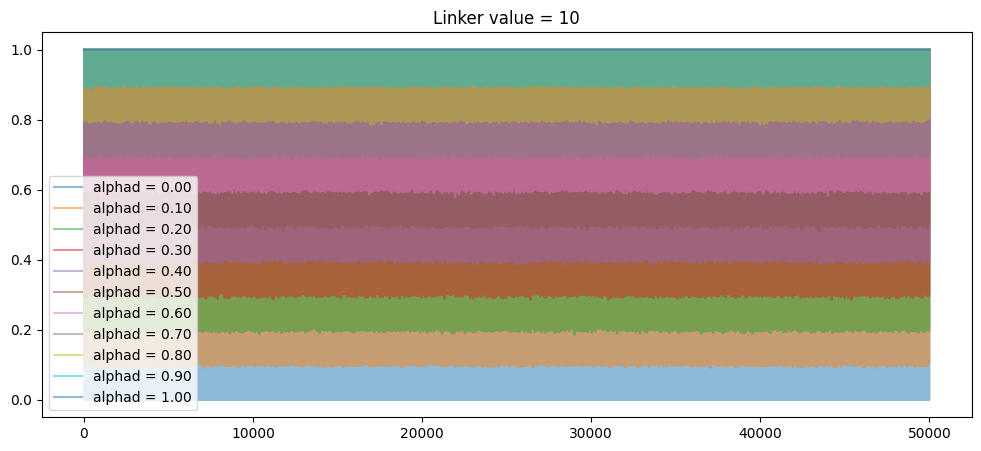

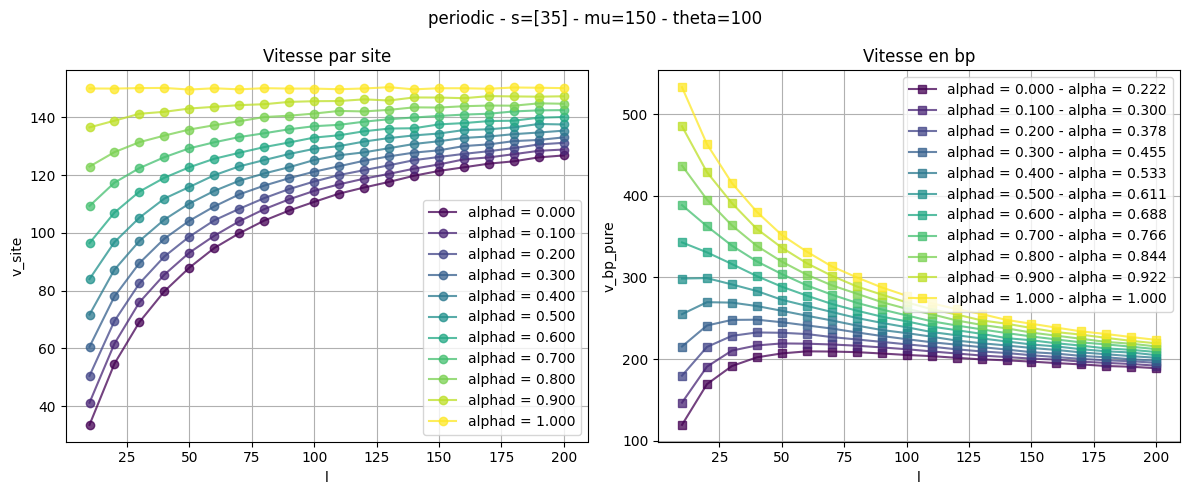

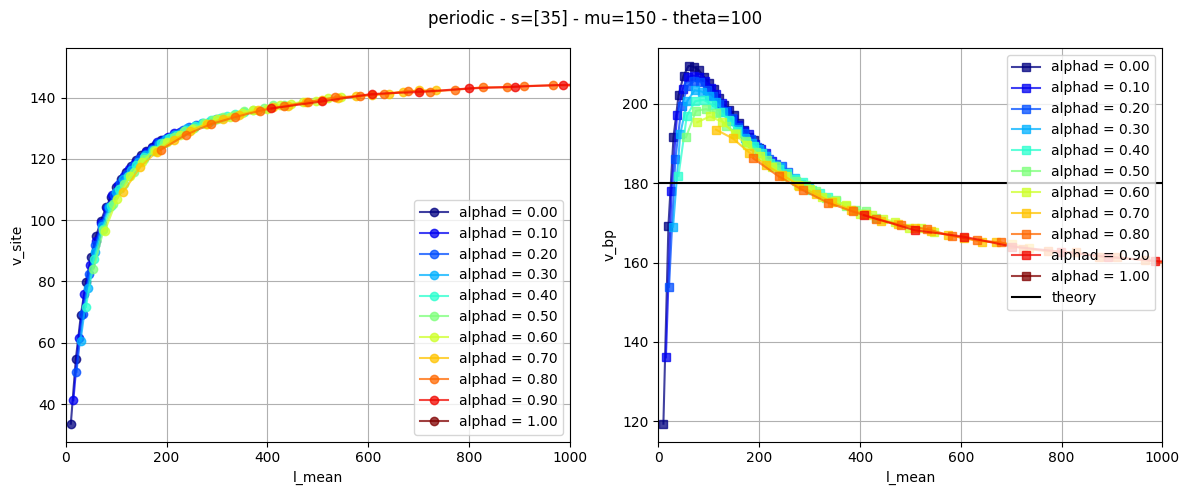

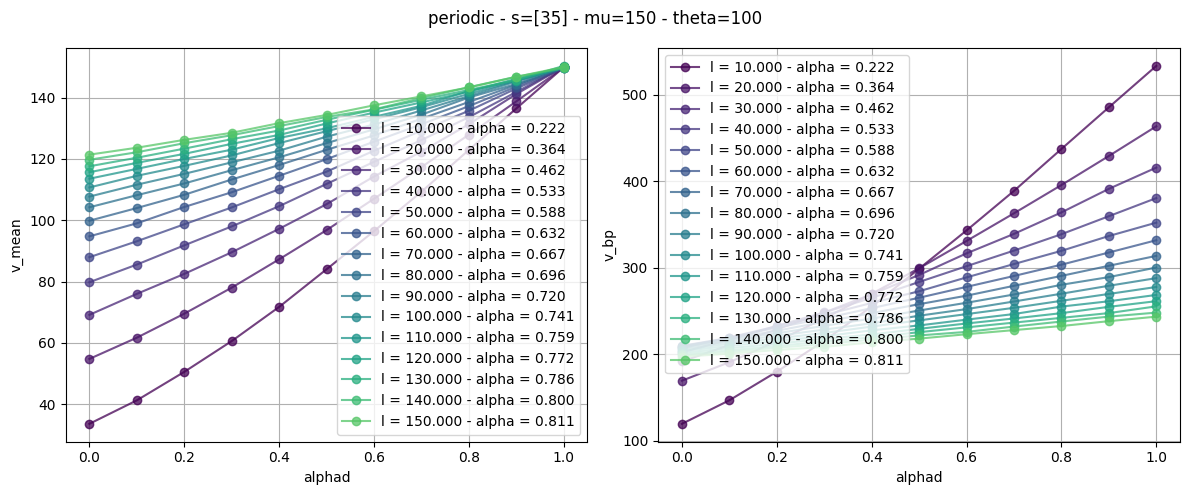

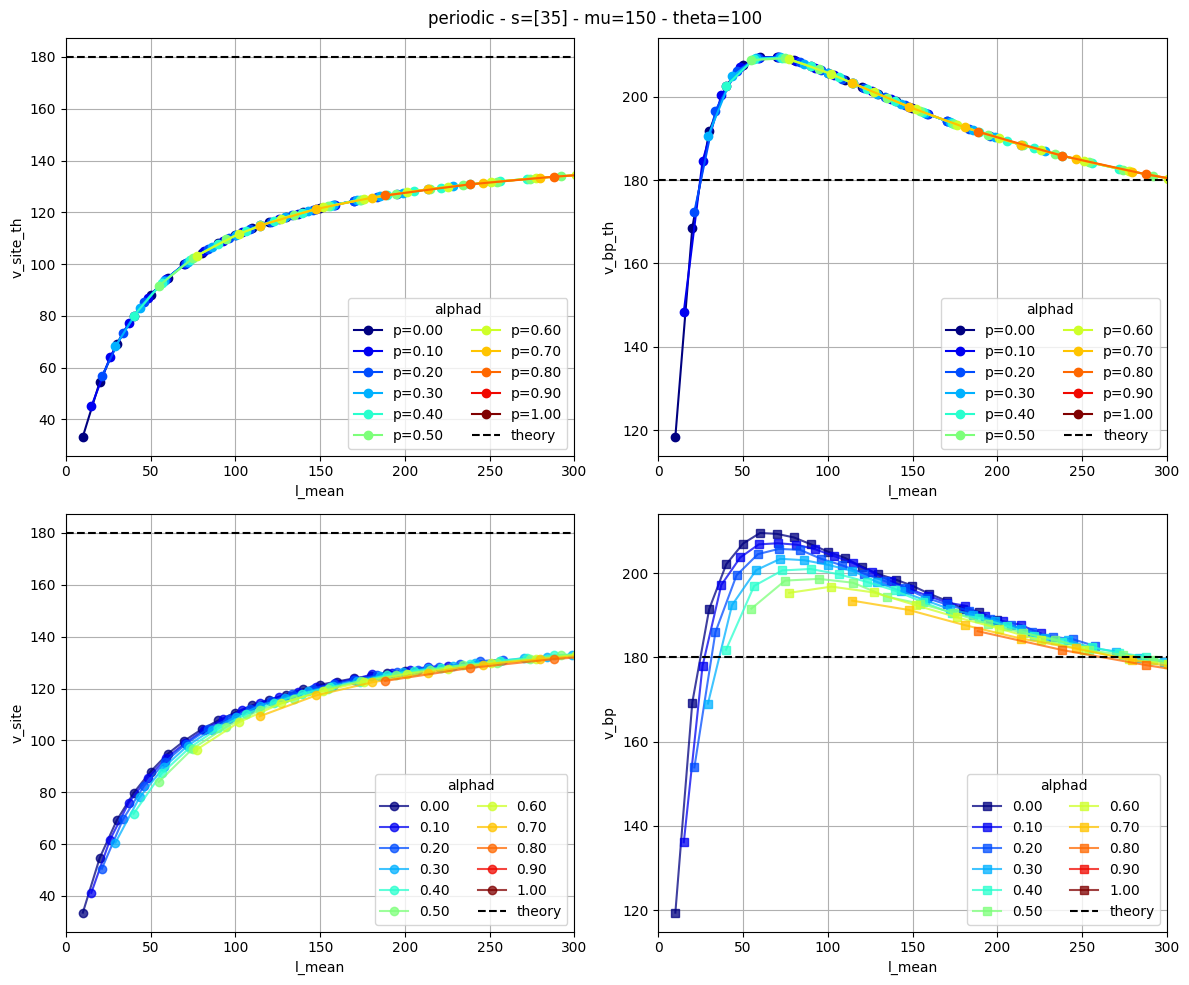

In [7]:
# ─────────────────────────────────────────────
# FIGURE 1 — Destruction des obstacles
# ─────────────────────────────────────────────

l_value = 10
df_sub  = df_periodic.filter(pl.col("l") == l_value)

plt.figure(figsize=(12, 5))

for row in df_sub.iter_rows(named=True):
    alpha_mean_a = row["alpha_mean_a"]
    alphad_val   = row["alphad"]
    alpha_value  = np.mean(alpha_mean_a)
    plt.plot(alpha_mean_a, alpha=0.50, label=f"alphad = {alphad_val:.2f}")
    print(f"alphad = {alphad_val:.2f} - alpha_value = {alpha_value:.2f} - {alpha_mean_a[0:100]}")

plt.title(f"Linker value = {l_value}")
plt.legend()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 2 — v_site et v_bp vs l
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle(f"{land} - s={s_values} - mu={mu} - theta={th}")

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad_val   = group["alphad"][0]
    l_bp         = group["l"].to_numpy()
    v_site       = group["v_mean"].to_numpy()
    alpha_mean_a = group["alpha_mean_a"].to_numpy()[0]
    alpha_value  = np.mean(alpha_mean_a)
    c            = (150 + l_bp) / (35 + l_bp)
    color        = cmap_viridis(norm_alphad(alphad_val))

    axs[0].plot(l_bp, v_site,      color=color, marker="o", ls="-", alpha=0.75, label=f"alphad = {alphad_val:.3f}")
    axs[1].plot(l_bp, v_site * c,  color=color, marker="s",          alpha=0.75, label=f"alphad = {alphad_val:.3f} - alpha = {alpha_value:.3f}")

axs[0].set_xlabel("l") ; axs[0].set_ylabel("v_site")    ; axs[0].set_title("Vitesse par site")
axs[1].set_xlabel("l") ; axs[1].set_ylabel("v_bp_pure") ; axs[1].set_title("Vitesse en bp")

for ax in axs:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 3 — v_site et v_bp vs l_mean
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle(f"{land} - s={s_values} - mu={mu} - theta={th}")

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad_val = group["alphad"][0]
    l_mean     = group["l_mean"].to_numpy()
    v_site     = group["v_mean"].to_numpy()
    c          = (150 + l_mean) / (35 + l_mean)
    color      = cmap_jet(norm_alphad(alphad_val))

    axs[0].plot(l_mean, v_site,      color=color, marker="o", ls="-", alpha=0.75, label=f"alphad = {alphad_val:.2f}")
    axs[1].plot(l_mean, v_site * c,  color=color, marker="s", ls="-", alpha=0.75, label=f"alphad = {alphad_val:.2f}")

axs[1].axhline(y=180, c="k", label="theory")

for ax in axs:
    ax.set_xlim([0, 1_000])
    ax.grid(True)
    ax.legend()

axs[0].set_xlabel("l_mean") ; axs[0].set_ylabel("v_site")
axs[1].set_xlabel("l_mean") ; axs[1].set_ylabel("v_bp")

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 4 — v_site et v_bp vs alphad
# ─────────────────────────────────────────────

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
plt.suptitle(f"{land} - s={s_values} - mu={mu} - theta={th}")

for group in df_subset.partition_by("l", as_dict=False):
    l_val        = group["l"][0]
    alphad_arr   = group["alphad"].to_numpy()
    v_site       = group["v_mean"].to_numpy()
    alpha_mean_a = group["alpha_mean_a"].to_numpy()[0]
    alpha_value  = np.mean(alpha_mean_a[10_000:20_000])
    c            = (150 + l_val) / (35 + l_val)
    color        = cmap_viridis(norm_l(l_val))
    label        = f"l = {l_val:.3f} - alpha = {alpha_value:.3f}"

    axs[0].plot(alphad_arr, v_site,      color=color, marker="o", alpha=0.75, label=label)
    axs[1].plot(alphad_arr, v_site * c,  color=color, marker="o", alpha=0.75, label=label)

axs[0].set_xlabel("alphad") ; axs[0].set_ylabel("v_mean")
axs[1].set_xlabel("alphad") ; axs[1].set_ylabel("v_bp")

for ax in axs:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────
# FIGURE 5 — Résultats principaux (2x2)
# ─────────────────────────────────────────────

xmax = 300

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.suptitle(f"{land} - s={s_values} - mu={mu} - theta={th}")
(ax1, ax2), (ax3, ax4) = axes

# ax1 : v_mean_th_eff vs l_mean  (df_subset)
# ax2 : v_mean_th_eff * c vs l_mean  (df_subset)
for group in df_subset.partition_by("alphad", as_dict=False):
    alphad_val   = group["alphad"][0]
    l_mean       = group["l_mean"].to_numpy()
    v_th_eff     = group["v_mean_th_eff"].to_numpy()
    c            = (150 + l_mean) / (35 + l_mean)
    color        = cmap_jet(norm_alphad(alphad_val))
    ax1.plot(l_mean, v_th_eff,       color=color, marker="o", label=f"p={alphad_val:.2f}")
    ax2.plot(l_mean, v_th_eff * c,   color=color, marker="o", label=f"p={alphad_val:.2f}")

# ax3 : v_site vs l_mean  (df_sorted)
# ax4 : v_bp vs l_mean  (df_sorted)
for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad_val = group["alphad"][0]
    l_mean     = group["l_mean"].to_numpy()
    v_site     = group["v_mean"].to_numpy()
    c          = (150 + l_mean) / (35 + l_mean)
    color      = cmap_jet(norm_alphad(alphad_val))
    ax3.plot(l_mean, v_site,      color=color, marker="o", ls="-", alpha=0.75, label=f"{alphad_val:.2f}")
    ax4.plot(l_mean, v_site * c,  color=color, marker="s", ls="-", alpha=0.75, label=f"{alphad_val:.2f}")

for ax, ylabel in zip([ax1, ax2, ax3, ax4], ["v_site_th", "v_bp_th", "v_site", "v_bp"]):
    ax.axhline(y=180, c="k", ls="--", label="theory")
    ax.set_xlim([0, xmax])
    ax.set_xlabel("l_mean")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend(title="alphad", ncols=2)

plt.tight_layout()
plt.show()

# RANDOM + PERIODIC : NEW METHOD

In [8]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path


# ─────────────────────────────────────────────
# PARAMETERS
# ─────────────────────────────────────────────

s_selected     = 35
mu_selected    = mu
theta_selected = theta
l_try     = 10

xlim_main = 500
xlim_sub  = 2_000

params_periodic = [0.0, 0.3, 0.6, 0.9]  # alphad
params_random   = [0, 10, 20]            # bpmin


# ─────────────────────────────────────────────
# READING FUNCTION
# ─────────────────────────────────────────────

def load_scalar_columns(paths, extra_cols=None):
    lf = pl.scan_parquet(paths)
    scalar_cols = [
        name for name, dtype in lf.schema.items()
        if isinstance(dtype, (
            pl.Int8, pl.Int16, pl.Int32, pl.Int64,
            pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
            pl.Float32, pl.Float64,
            pl.Boolean, pl.Utf8
        ))
    ]
    if extra_cols is not None:
        if isinstance(extra_cols, str):
            extra_cols = [extra_cols]
        scalar_cols = list(set(scalar_cols + extra_cols))
    return lf.select(scalar_cols).collect()


# ─────────────────────────────────────────────
# DATA FRAMES
# ─────────────────────────────────────────────

df_compaction = (
    load_scalar_columns(paths, extra_cols=None)
    .sort(["land", "bpmin", "l", "alphad"])
    .filter(
        (pl.col("s")     == s_selected)     &
        (pl.col("mu")    == mu_selected)    &
        (pl.col("theta") == theta_selected)
    )
)

df_periodic = (
    df_compaction
    .filter(pl.col("land") == "periodic")
    .with_columns(pl.col("alphad").round(3))
    .filter(pl.col("alphad").is_in(params_periodic))
)

df_random = (
    df_compaction
    .filter(pl.col("land") == "random")
    .with_columns(pl.col("bpmin").round(3))
    .filter(pl.col("bpmin").is_in(params_random))
)

/tmp/ipykernel_131943/2280777105.py:35: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  name for name, dtype in lf.schema.items()


/tmp/ipykernel_131943/3309908817.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


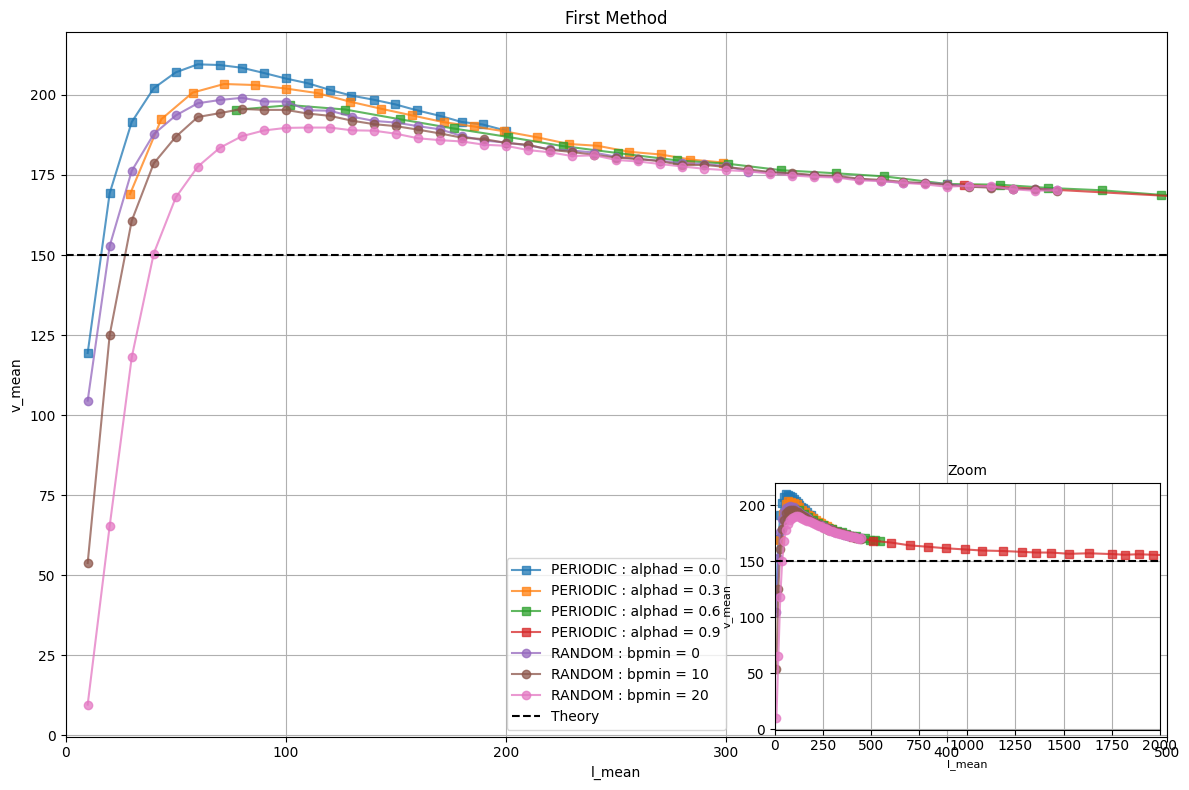

In [9]:
# ─────────────────────────────────────────────
# FIGURE - FIRST METHOD
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 8))


# ── Main ──────────────────────────────────────

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad = group["alphad"][0]
    l_mean = group["l_mean"].to_numpy()
    v_bp   = group["v_mean"].to_numpy() * (150 + l_mean) / (s_selected + l_mean)
    ax.plot(l_mean, v_bp, marker="s", ls="-", alpha=0.75, label=f"PERIODIC : alphad = {alphad}")

for group in df_random.partition_by("bpmin", as_dict=False):
    bpmin  = group["bpmin"][0]
    l_mean = group["l"].to_numpy()
    v_bp   = group["v_mean"].to_numpy() * (150 + l_mean) / (s_selected + l_mean)
    ax.plot(l_mean, v_bp, marker="o", ls="-", alpha=0.75, label=f"RANDOM : bpmin = {bpmin}")

ax.axhline(mu_selected, c="k", ls="--", label="Theory")
ax.set_title("First Method")
ax.set_xlim([0, xlim_main])
ax.set_xlabel("l_mean")
ax.set_ylabel("v_mean")
ax.legend(loc="lower center")
ax.grid(True)


# ── Inset ─────────────────────────────────────

ax_inset = inset_axes(ax, width="35%", height="35%", loc="lower right")

for group in df_periodic.partition_by("alphad", as_dict=False):
    l_mean = group["l_mean"].to_numpy()
    v_bp   = group["v_mean"].to_numpy() * (150 + l_mean) / (s_selected + l_mean)
    ax_inset.plot(l_mean, v_bp, marker="s", ls="-", alpha=0.75)

for group in df_random.partition_by("bpmin", as_dict=False):
    l_mean = group["l"].to_numpy()
    v_bp   = group["v_mean"].to_numpy() * (150 + l_mean) / (s_selected + l_mean)
    ax_inset.plot(l_mean, v_bp, marker="o", ls="-", alpha=0.75)

ax_inset.axhline(mu_selected, c="k", ls="--")
ax_inset.set_xlim([0, xlim_sub])
ax_inset.set_ylim(ax.get_ylim())
ax_inset.set_xlabel("l_mean", fontsize=8)
ax_inset.set_ylabel("v_mean", fontsize=8)
ax_inset.set_title("Zoom", fontsize=10)
ax_inset.grid(True)


plt.tight_layout()
plt.show()

/tmp/ipykernel_131943/554424664.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


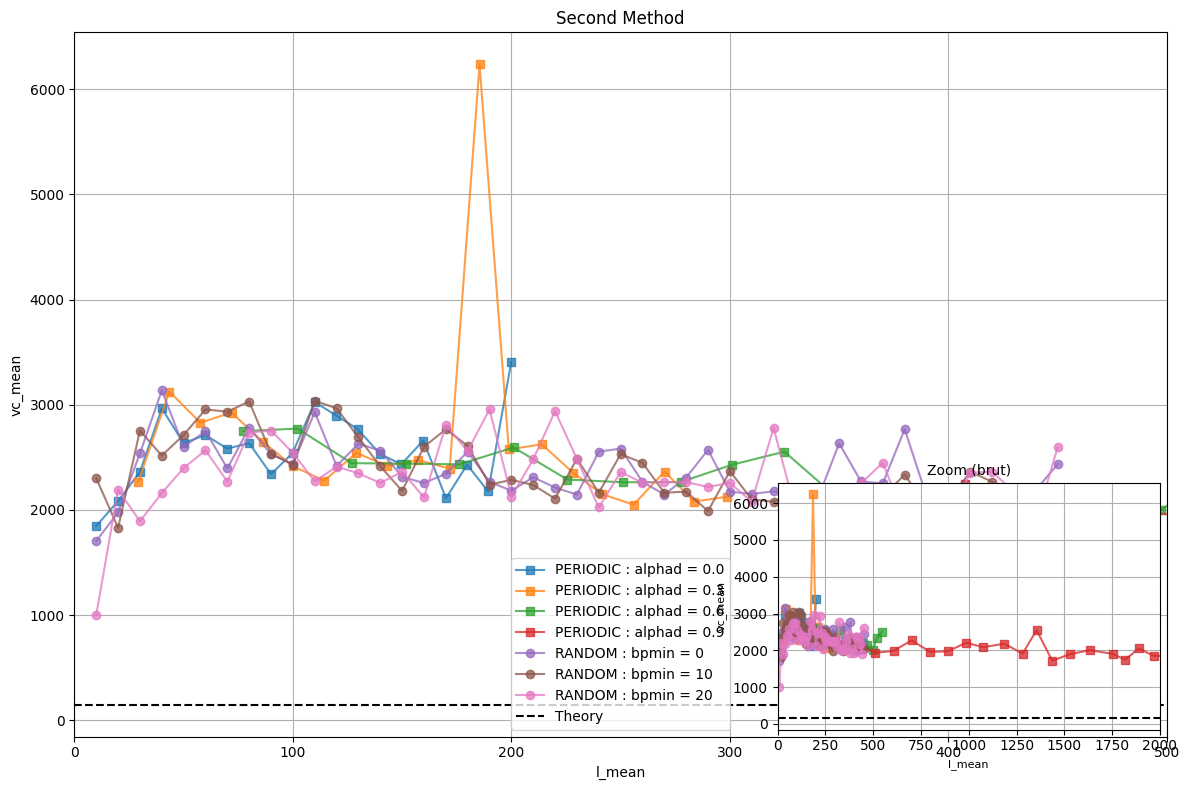

In [10]:
# ─────────────────────────────────────────────
# FIGURE - SECOND METHOD
# ─────────────────────────────────────────────

v_to_plot   = "vc_mean"
theo_value  = mu_selected


fig, ax = plt.subplots(figsize=(12, 8))


# ── Main ──────────────────────────────────────

for group in df_periodic.partition_by("alphad", as_dict=False):
    alphad  = group["alphad"][0]
    l_mean  = group["l_mean"].to_numpy()
    vc      = group[v_to_plot].to_numpy()
    ax.plot(l_mean, vc, marker="s", ls="-", alpha=0.75, label=f"PERIODIC : alphad = {alphad}")

for group in df_random.partition_by("bpmin", as_dict=False):
    bpmin   = group["bpmin"][0]
    l_mean  = group["l"].to_numpy()
    vc      = group[v_to_plot].to_numpy()
    ax.plot(l_mean, vc, marker="o", ls="-", alpha=0.75, label=f"RANDOM : bpmin = {bpmin}")

ax.axhline(theo_value, c="k", ls="--", label="Theory")
ax.set_title("Second Method")
ax.set_xlim([0, xlim_main])
ax.set_xlabel("l_mean")
ax.set_ylabel(v_to_plot)
ax.legend(loc="lower center")
ax.grid(True)


# ── Inset ─────────────────────────────────────

ax_inset = inset_axes(ax, width="35%", height="35%", loc="lower right")

for group in df_periodic.partition_by("alphad", as_dict=False):
    l_mean  = group["l_mean"].to_numpy()
    vc      = group[v_to_plot].to_numpy()
    ax_inset.plot(l_mean, vc, marker="s", ls="-", alpha=0.75)

for group in df_random.partition_by("bpmin", as_dict=False):
    l_mean  = group["l"].to_numpy()
    vc      = group[v_to_plot].to_numpy()
    ax_inset.plot(l_mean, vc, marker="o", ls="-", alpha=0.75)

ax_inset.axhline(theo_value, c="k", ls="--", label="Theory")
ax_inset.set_xlim([0, xlim_sub])
ax_inset.set_xlabel("l_mean", fontsize=8)
ax_inset.set_ylabel(v_to_plot, fontsize=8)
ax_inset.set_title("Zoom (brut)", fontsize=10)
ax_inset.grid(True)


plt.tight_layout()
plt.show()

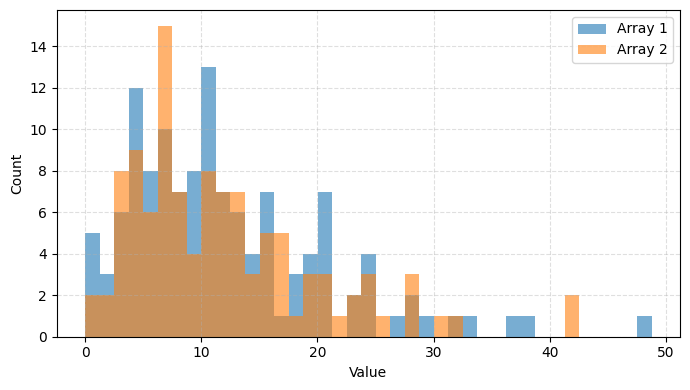

In [11]:
import numpy as np
import matplotlib.pyplot as plt

raw1 = np.array([
 [ 0.,  11.426185,  13.255024,       np.nan,      np.nan],
 [ 0.,  36.952465,       np.nan,      np.nan,      np.nan],
 [ 0.,  15.690334,       np.nan,      np.nan,      np.nan],
 [ 0.,  20.848452,   8.9994545,      np.nan,      np.nan],
 [ 0.,   6.0208426,      np.nan,      np.nan,      np.nan],
 [ 0.,  18.9549,     1.0577087,      np.nan,      np.nan],
 [ 0.,  11.181428,  16.259636,       np.nan,      np.nan],
 [ 0.,  10.519662,  10.735008,   2.6144295,   9.14299  ],
 [ 0.,   1.1205292,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  26.837563,       np.nan,      np.nan,      np.nan],
 [ 0.,  15.106265,       np.nan,      np.nan,      np.nan],
 [ 0.,  15.425785,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   5.3375883,  6.9257803,  25.010677,       np.nan],
 [ 0.,   5.571457,       np.nan,      np.nan,      np.nan],
 [ 0.,  19.623795,  12.522076,       np.nan,      np.nan],
 [ 0.,  10.586293,  31.347658,       np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   7.727254,   6.197445,       np.nan,      np.nan],
 [ 0.,   3.8052902, 11.996895,       np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   2.4907532,      np.nan,      np.nan,      np.nan],
 [ 0.,  14.902327,       np.nan,      np.nan,      np.nan],
 [ 0.,   6.066924,       np.nan,      np.nan,      np.nan],
 [ 0.,   3.1982155,      np.nan,      np.nan,      np.nan],
 [ 0.,   9.391666,  10.771973,       np.nan,      np.nan],
 [ 0.,   3.1097565,  7.852745,       np.nan,      np.nan],
 [ 0.,  48.790962,   3.2997818,      np.nan,      np.nan],
 [ 0.,   6.672386,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  10.83993,        np.nan,      np.nan,      np.nan],
 [ 0.,   9.21018,    7.327282,       np.nan,      np.nan],
 [ 0.,   9.804605,       np.nan,      np.nan,      np.nan],
 [ 0.,   3.0068054,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  24.821644,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   4.7621136,      np.nan,      np.nan,      np.nan],
 [ 0.,  11.797104,       np.nan,      np.nan,      np.nan],
 [ 0.,   4.9605675,      np.nan,      np.nan,      np.nan],
 [ 0.,  17.737,          np.nan,      np.nan,      np.nan],
 [ 0.,  22.759476,   3.8025818,      np.nan,      np.nan],
 [ 0.,  10.42242,        np.nan,      np.nan,      np.nan],
 [ 0.,   5.6182175, 14.98726,    0.07712936,  7.601906 ],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  11.507557,  16.108349,       np.nan,      np.nan],
 [ 0.,  11.062714,  15.546494,       np.nan,      np.nan],
 [ 0.,   7.085084,  13.015198,       np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  14.880777,       np.nan,      np.nan,      np.nan],
 [ 0.,   6.9235954,      np.nan,      np.nan,      np.nan],
 [ 0.,   2.6237168, 12.271927,       np.nan,      np.nan],
 [ 0.,  13.531474,   4.257057,   2.4650116,      np.nan],
 [ 0.,  23.674593,  15.850521,   6.948143,       np.nan],
 [ 0.,   4.354748,       np.nan,      np.nan,      np.nan],
 [ 0.,  12.776062,       np.nan,      np.nan,      np.nan],
 [ 0.,   6.467865,       np.nan,      np.nan,      np.nan],
 [ 0.,  20.635323,       np.nan,      np.nan,      np.nan],
 [ 0.,  20.68467,   38.16903,        np.nan,      np.nan],
 [ 0.,  20.26957,        np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   8.969658,       np.nan,      np.nan,      np.nan],
 [ 0.,  18.564156,  29.053833,       np.nan,      np.nan],
 [ 0.,   8.50359,        np.nan,      np.nan,      np.nan],
 [ 0.,  13.09888,   23.796795,       np.nan,      np.nan],
 [ 0.,  10.226082,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  24.540611,       np.nan,      np.nan,      np.nan],
 [ 0.,  10.839077,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   3.9037032,  3.7918673,      np.nan,      np.nan],
 [ 0.,  20.325424,   5.743492,       np.nan,      np.nan],
 [ 0.,  11.956955,       np.nan,      np.nan,      np.nan],
 [ 0.,   6.3670125,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  12.288425,   8.183361,  10.284157,   4.199486 ],
 [ 0.,   3.8059464,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  14.987761,  33.16809,    9.660912,   6.5967865],
 [ 0.,   5.838373,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   4.1619787,  1.2282257,      np.nan,      np.nan],
 [ 0.,  27.890095,       np.nan,      np.nan,      np.nan],
 [ 0.,  10.817181,       np.nan,      np.nan,      np.nan],
 [ 0.,  20.142275,   9.330227,   3.8815804,      np.nan],
 [ 0.,   7.121788,   0.75510406,19.271622,       np.nan],
 [ 0.,  27.843822,       np.nan,      np.nan,      np.nan],
 [ 0.,  10.940811,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  19.850897,   8.607643,       np.nan,      np.nan],
 [ 0.,  20.82566,        np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   8.58614,        np.nan,      np.nan,      np.nan],
 [ 0.,  18.351854,   1.9835052,  16.497925,      np.nan],
])

raw2 = np.array([
 [ 0.,  17.385025,  16.198082,       np.nan,      np.nan],
 [ 0.,   7.200922,  10.863937,       np.nan,      np.nan],
 [ 0.,  11.541584,  16.539633,   3.1239777,      np.nan],
 [ 0.,   4.4709063, 28.021076,       np.nan,      np.nan],
 [ 0.,  20.041384,  14.67647,    1.6632919,  27.57235 ],
 [ 0.,   5.9907227,      np.nan,      np.nan,      np.nan],
 [ 0.,  13.112694,       np.nan,      np.nan,      np.nan],
 [ 0.,  11.937958,  10.727402,       np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   7.5956783,  7.862278,       np.nan,      np.nan],
 [ 0.,  10.64846,        np.nan,      np.nan,      np.nan],
 [ 0.,  16.387302,   7.4646797,      np.nan,      np.nan],
 [ 0.,   4.082039,       np.nan,      np.nan,      np.nan],
 [ 0.,  30.029112,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   3.1584358,      np.nan,      np.nan,      np.nan],
 [ 0.,  15.030785,  16.057278,   1.9009018,      np.nan],
 [ 0.,  10.959934,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   1.1565285,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   6.6596575,  4.5741596,      np.nan,      np.nan],
 [ 0.,  31.40194,    2.5910034,  13.518684,  17.525276],
 [ 0.,  23.894943,       np.nan,      np.nan,      np.nan],
 [ 0.,   9.389155,   5.231019,   9.162209,       np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   7.11088,    6.634033,   3.5698395,      np.nan],
 [ 0.,   4.648307,       np.nan,      np.nan,      np.nan],
 [ 0.,  24.023243,   3.4456635,  16.590813,      np.nan],
 [ 0.,  12.095055,  41.915688,       np.nan,      np.nan],
 [ 0.,   8.996741,       np.nan,      np.nan,      np.nan],
 [ 0.,   5.672268,   8.451546,       np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   5.227516,       np.nan,      np.nan,      np.nan],
 [ 0.,   9.233177,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  23.417376,       np.nan,      np.nan,      np.nan],
 [ 0.,   4.8900084,  5.7686615,  6.2836494,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  14.000984,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  12.366856,  10.256699,       np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  11.406738,       np.nan,      np.nan,      np.nan],
 [ 0.,  10.534664,       np.nan,      np.nan,      np.nan],
 [ 0.,   7.2114105, 13.553375,       np.nan,      np.nan],
 [ 0.,  12.961844,       np.nan,      np.nan,      np.nan],
 [ 0.,  20.348488,       np.nan,      np.nan,      np.nan],
 [ 0.,   2.8109055,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  16.978891,  18.822823,       np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   3.9337006,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  10.887947,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  28.236036,   8.204639,  20.659393,      np.nan],
 [ 0.,   2.9973774,      np.nan,      np.nan,      np.nan],
 [ 0.,   7.1703796,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  19.246807,       np.nan,      np.nan,      np.nan],
 [ 0.,   3.072567,       np.nan,      np.nan,      np.nan],
 [ 0.,  42.37548,    0.6259918,  11.591904,  15.364502],
 [ 0.,  12.66922,        np.nan,      np.nan,      np.nan],
 [ 0.,   4.7196584,  5.4510326,  7.515049,       np.nan],
 [ 0.,   6.844517,  12.936722,       np.nan,      np.nan],
 [ 0.,   6.4639025, 14.280624,       np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   6.303091,       np.nan,      np.nan,      np.nan],
 [ 0.,   7.3270874,      np.nan,      np.nan,      np.nan],
 [ 0.,   6.435047,       np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  21.772953,  15.647057,  10.667114,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   7.1450963,      np.nan,      np.nan,      np.nan],
 [ 0.,   6.6126175,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  11.467794,  19.270477,       np.nan,      np.nan],
 [ 0.,   7.8333416, 25.983616,  24.63079,       np.nan],
 [ 0.,   4.9357243,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,   8.491692,  22.894775,       np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,       np.nan,      np.nan,      np.nan,      np.nan],
 [ 0.,  13.652508,       np.nan,      np.nan,      np.nan],
 [ 0.,   4.6280785,      np.nan,      np.nan,      np.nan],
])

# Flatten, drop col 0 (always 0) and NaNs
def extract(arr):
    vals = arr[:, 1:].flatten()
    return vals[~np.isnan(vals)]

v1 = extract(raw1)
v2 = extract(raw2)

bins = np.linspace(0, max(v1.max(), v2.max()), 40)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(v1, bins=bins, alpha=0.6, label="Array 1")
ax.hist(v2, bins=bins, alpha=0.6, label="Array 2")
ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

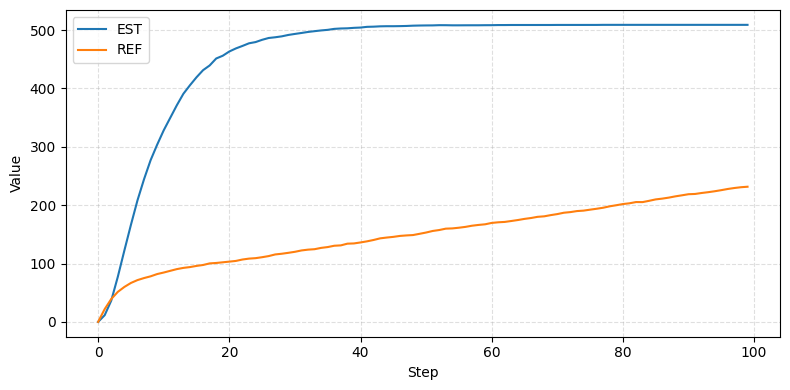

In [12]:
import numpy as np
import matplotlib.pyplot as plt

EST = np.array([
      0.        ,  11.44321424,  36.39909994,  77.16129987, 122.26495676,
    166.2865279 , 208.26098479, 244.53419881, 277.08317004, 303.65895559,
    328.3355841 , 349.82006972, 371.28364097, 390.9668837 , 405.54178345,
    419.21929755, 431.39248321, 439.42986888, 451.39404005, 456.12128295,
    463.40234006, 468.64551147, 472.90418286, 477.43843995, 479.5277685 ,
    483.41538287, 486.54495427, 487.78093998, 489.36913997, 491.76045427,
    493.50305426, 495.13529706, 496.89716846, 498.22315415, 499.4954112 ,
    500.50249686, 502.16806831, 502.84028259, 503.13971115, 503.93703971,
    504.42568256, 505.64836829, 505.94579686, 506.52681116, 506.73875402,
    506.71666831, 506.88509688, 507.1559826 , 507.64921117, 507.91065402,
    508.05702545, 508.13038259, 508.49615403, 508.45252546, 508.24726831,
    508.24726831, 508.31343974, 508.34371117, 508.34371117, 508.46179689,
    508.49573974, 508.71813974, 508.71813974, 508.8185826 , 508.8185826 ,
    508.8185826 , 508.8185826 , 508.8185826 , 508.8345826 , 508.8345826 ,
    508.91765403, 508.91765403, 508.91765403, 508.91765403, 508.91765403,
    508.9318826 , 508.9318826 , 509.0584826 , 509.0584826 , 509.0584826 ,
    509.0584826 , 509.0584826 , 509.0584826 , 509.0584826 , 509.0584826 ,
    509.0584826 , 509.0584826 , 509.0584826 , 509.0584826 , 509.0584826 ,
    509.0584826 , 509.0584826 , 509.0584826 , 509.0584826 , 509.0584826 ,
    509.0584826 , 509.0584826 , 509.0584826 , 509.0584826 , 509.0584826 ,
])

REF = np.array([
      0.    ,  21.8791,  39.1594,  51.4112,  59.8601,  66.6933,  71.603 ,  75.0928,
     78.0505,  81.9507,  84.5635,  87.5083,  90.4153,  92.5258,  93.903 ,  95.9152,
     97.4832, 100.207 , 100.9525, 102.0964, 103.2441, 104.4457, 106.8604, 108.4125,
    109.191 , 110.8321, 112.7579, 115.566 , 116.7763, 118.3454, 120.0865, 122.4118,
    123.7851, 124.5597, 126.8128, 128.2152, 130.4767, 131.0984, 134.0217, 134.4365,
    136.1236, 138.0489, 140.3752, 143.1641, 144.5192, 145.6826, 147.2912, 148.1576,
    148.7848, 150.9147, 153.1249, 155.7871, 157.4057, 159.7648, 160.1882, 161.3598,
    162.8024, 164.8017, 166.1508, 167.2315, 169.5858, 170.6655, 171.3099, 172.8976,
    174.5608, 176.5025, 178.006 , 180.0284, 180.8821, 182.9598, 184.7299, 187.055 ,
    188.143 , 189.8977, 190.6517, 192.3113, 193.8785, 195.631 , 198.0719, 199.9221,
    201.919 , 203.2131, 205.3476, 205.2691, 207.4776, 209.9006, 211.2309, 212.9666,
    215.1221, 216.9041, 218.7847, 219.2245, 220.885 , 222.2586, 223.8771, 225.7397,
    227.7899, 229.4353, 230.7734, 231.616 ,
])

steps = np.arange(len(EST))
steps_ref = np.arange(len(REF))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps,     EST, label="EST")
ax.plot(steps_ref, REF, label="REF")
ax.set_xlabel("Step")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# .